                                                           NLP
                                 (TEXT CLASSIFICATION AND SENTIMENT ANALYSIS)

1.Import Libraries

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud


2.Load Dataset

In [6]:
df = pd.read_csv("amazonreviews.tsv", sep='\t', encoding='latin-1')
print(df.head())

  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...


In [8]:
print(df.shape)

(10000, 2)


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None


In [12]:
print(df.columns)

Index(['label', 'review'], dtype='object')


3.Data Cleaning :
Check Missing Values, Remove Missing & Duplicates, Download Stopwords,Text Cleaning Function

In [15]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [17]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [19]:
df.shape

(10000, 2)

In [21]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LAP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
def clean_text(text):
    text = text.lower()                         # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)      # remove special characters
    words = text.split()                        # tokenize
    words = [word for word in words if word not in stop_words]  # remove stopwords
    return " ".join(words)

df['cleaned_review'] = df['review'].apply(clean_text)


In [24]:
df[['review','cleaned_review']].head()

,review,cleaned_review
0,Stuning even for the non-gamer: This sound tra...,stuning even non gamer sound track beautiful p...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything reading lot revi...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing played game kn...


4.Exploratory Data Analysis (EDA):
Sentiment Distribution,
Word Cloud – Positive Reviews,
Word Cloud – Negative Reviews.

In [28]:
df['label'].value_counts()


label
neg    5097
pos    4903
Name: count, dtype: int64

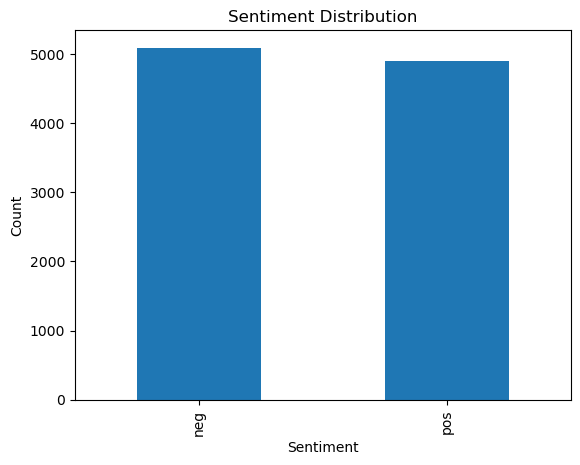

In [30]:
df['label'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


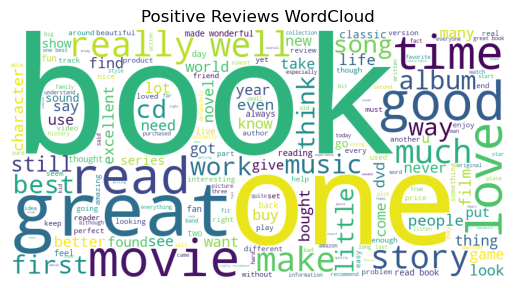

In [32]:
positive_text = " ".join(df[df['label']=='pos']['cleaned_review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()


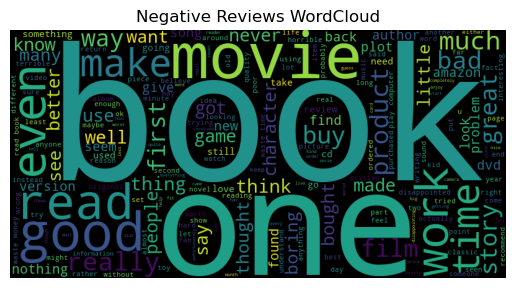

In [34]:
negative_text = " ".join(df[df['label']=='neg']['cleaned_review'])

wordcloud = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()


In [36]:
from collections import Counter

positive_words = positive_text.split()

top_positive = Counter(positive_words).most_common(20)

print("Top 20 Positive Words:")
print(top_positive)


Top 20 Positive Words:
[('book', 3390), ('great', 2135), ('one', 1916), ('good', 1667), ('read', 1605), ('like', 1290), ('movie', 1121), ('would', 956), ('well', 944), ('time', 924), ('love', 911), ('really', 832), ('best', 813), ('get', 805), ('story', 730), ('first', 724), ('much', 664), ('cd', 618), ('music', 577), ('also', 575)]


In [38]:
negative_words = negative_text.split()

top_negative = Counter(negative_words).most_common(20)

print("Top 20 Negative Words:")
print(top_negative)


Top 20 Negative Words:
[('book', 3277), ('one', 2100), ('like', 1569), ('movie', 1519), ('would', 1465), ('read', 1222), ('good', 1160), ('get', 1151), ('time', 1072), ('even', 910), ('buy', 835), ('really', 783), ('much', 782), ('money', 767), ('bad', 764), ('first', 760), ('better', 677), ('could', 667), ('great', 644), ('story', 641)]


In [47]:
pos_df = pd.DataFrame(top_positive, columns=['Word', 'Frequency'])
pos_df

,Word,Frequency
0,book,3390
1,great,2135
2,one,1916
3,good,1667
4,read,1605
5,like,1290
6,movie,1121
7,would,956
8,well,944
9,time,924


In [49]:
neg_df = pd.DataFrame(top_negative, columns=['Word', 'Frequency'])
neg_df


,Word,Frequency
0,book,3277
1,one,2100
2,like,1569
3,movie,1519
4,would,1465
5,read,1222
6,good,1160
7,get,1151
8,time,1072
9,even,910


5.Feature Extraction :

In [52]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_review'])
y = df['label']


6.Train-Test Split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


7.Model Development
Model 1: Logistic Regression
Model 2: SVM

In [58]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)


In [60]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)


8.Model Evaluation

In [63]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.851
              precision    recall  f1-score   support

         neg       0.85      0.86      0.86      1037
         pos       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

[[894 143]
 [155 808]]


In [65]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))


SVM Accuracy: 0.8525
              precision    recall  f1-score   support

         neg       0.86      0.85      0.86      1037
         pos       0.84      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

[[885 152]
 [143 820]]


9.Cross Validation

In [68]:
cv_scores = cross_val_score(lr_model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())


Cross Validation Scores: [0.8595 0.83   0.827  0.8455 0.8505]
Average CV Accuracy: 0.8424999999999999


10.Predict New Review

In [71]:
new_review = ["This product is amazing and works perfectly"]

new_review_clean = clean_text(new_review[0])
new_vector = vectorizer.transform([new_review_clean])

prediction = lr_model.predict(new_vector)

print("Predicted Sentiment:", prediction[0])


Predicted Sentiment: pos


In [77]:
import joblib

joblib.dump(lr_model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']

In [79]:
#Confusion Matrix
import 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


NameError: name 'sns' is not defined

In [367]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

In [370]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [372]:
y_pred = model.predict(X_test)


In [374]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8535


In [376]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, pos_label='pos')
print("F1 Score:", f1)


F1 Score: 0.849820604818042
